In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy import units as u

In [6]:
stem = '/Users/eckhartspalding/Documents/git.repos/nice/data/'

In [39]:
trans_ne13a = pd.read_csv(stem + 'trans_thorlabs_ne13a.csv', sep='\s+')
trans_ne20a = pd.read_csv(stem + 'trans_thorlabs_ne20a.csv', sep='\s+')
trans_ne30a = pd.read_csv(stem + 'trans_thorlabs_ne30a.csv', sep='\s+')
trans_ndir30a = pd.read_csv(stem + 'trans_thorlabs_ndir30a.csv', sep='\s+')


In [40]:
# make columns in units of interest
trans_ne13a['wavel_um'] = 1e-3 * trans_ne13a['wavel_nm']
trans_ne13a['trans'] = 1e-2 * trans_ne13a['percent_transmission']
trans_ne20a['wavel_um'] = 1e-3 * trans_ne20a['wavel_nm']
trans_ne20a['trans'] = 1e-2 * trans_ne20a['percent_transmission']
trans_ne30a['wavel_um'] = 1e-3 * trans_ne30a['wavel_nm']
trans_ne30a['trans'] = 1e-2 * trans_ne30a['percent_transmission']
trans_ndir30a['wavel_um'] = 1e-3 * trans_ndir30a['wavel_nm']
trans_ndir30a['trans'] = 1e-2 * trans_ndir30a['percent_transmission']


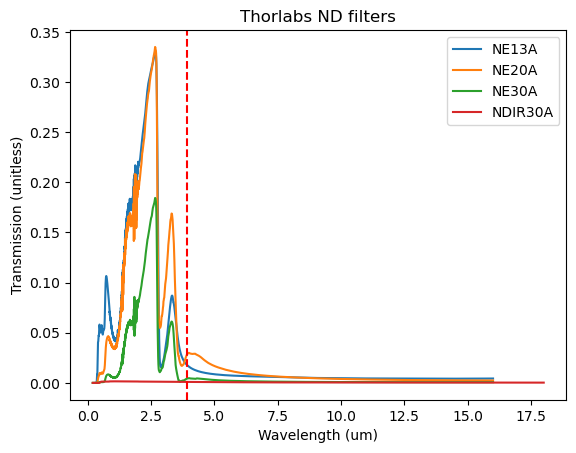

In [41]:
plt.plot(trans_ne13a['wavel_um'], trans_ne13a['trans'], label='NE13A')
plt.plot(trans_ne20a['wavel_um'], trans_ne20a['trans'], label='NE20A')
plt.plot(trans_ne30a['wavel_um'], trans_ne30a['trans'], label='NE30A')
plt.plot(trans_ndir30a['wavel_um'], trans_ndir30a['trans'], label='NDIR30A')
plt.axvline(x=3.9, color='r', linestyle='--')
plt.legend()
plt.xlabel('Wavelength (um)')
plt.ylabel('Transmission (unitless)')
plt.title('Thorlabs ND filters')
plt.show()


In [42]:
# interpolate the trans_ne13a['percent_transmission'] for the value at a wavelength of N um
def interp_trans(target_um, trans_df):
    # Interpolate percent_transmission at the target wavelength (um), converting nm to um
    interp_trans = np.interp(target_um, trans_df['wavel_um'], trans_df['trans'])
    return interp_trans


In [43]:
# Interpolate percent_transmission at the target wavelength (um), converting nm to um
target_um = 3.9 # wavelength of interest
trans_laser_ne13a = np.interp(target_um, trans_ne13a['wavel_um'], trans_ne13a['trans'])
trans_laser_ne20a = np.interp(target_um, trans_ne20a['wavel_um'], trans_ne20a['trans'])
trans_laser_ne30a = np.interp(target_um, trans_ne30a['wavel_um'], trans_ne30a['trans'])
trans_laser_ndir30a = np.interp(target_um, trans_ndir30a['wavel_um'], trans_ndir30a['trans'])
print(trans_laser_ne13a)
print(trans_laser_ne20a)
print(trans_laser_ne30a)
print(trans_laser_ndir30a)

0.018351551838429826
0.027553938772250337
0.0041609707748060725
0.0010098448867806227


In [45]:
# equivalent NDs

ND_ne13a = - np.log10(trans_laser_ne13a)
ND_ne20a = - np.log10(trans_laser_ne20a)
ND_ne30a = - np.log10(trans_laser_ne30a)
ND_ndir30a = - np.log10(trans_laser_ndir30a)

In [46]:
print(ND_ne13a)
print(ND_ne20a)
print(ND_ne30a)
print(ND_ndir30a)

1.7363272051791567
1.5598163109760537
2.3808053345278957
2.9957453291764007
